Importações

In [1]:
#Básico
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
# from ydata_profiling import ProfileReport

#Pipeline 
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, top_k_accuracy_score)


#Transformação de Dados
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Redução de Dimensionalidade
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap

# Técnicas de Balanceamento (imblearn)
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTEENN


#Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import Lasso
from sklearn.ensemble import VotingClassifier


c:\Users\anate\miniconda3\envs\IntroAProgGenetic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
optuna.logging.set_verbosity(optuna.logging.INFO)

# Pré-processamento

1. Leitura do Data frame e exclusão de linhas NA

In [3]:
df= pd.read_csv('dados_compilados.csv')
df_embeddings= pd.read_csv('embeddings_vit_fixed.csv')

In [4]:
df.head()

,filename,ACI,ADI,AEI,BIO,ANTHROPHONY,BIOPHONY,NDSI,RUGOSITY,MEAN_PSD,...,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,AR,class
0,Bells-0001.wav,41820.092394,0.571613,0.379943,5.228973,0.0,0.0,0.0,0.006131,41.911717,...,-10.003933,4.058826,-15.715445,3.225631,-15.853145,4.426826,-10.051934,10.185259,0.150590,Bells
1,Bells-0002.wav,0.000000,0.503497,0.384547,2.251788,0.0,0.0,0.0,0.005408,53.909118,...,-17.252598,8.563165,-8.428351,7.156574,-12.725844,6.464332,-16.255757,5.360357,0.411673,Bells
2,Bells-0003.wav,0.000000,0.525686,0.385269,3.271021,0.0,0.0,0.0,0.004579,67.712059,...,-16.333861,4.736877,-13.759465,4.308475,-13.420119,7.535614,-13.752654,6.984496,0.279350,Bells
3,Bells-0004.wav,43390.134239,0.806457,0.296183,6.980413,0.0,0.0,0.0,0.012099,7.807773,...,-4.781282,0.049894,-7.695588,12.685477,-8.879046,12.137831,-0.730996,9.400001,0.302294,Bells
4,Bells-0005.wav,0.000000,1.145673,0.041833,3.904934,0.0,0.0,0.0,0.028231,48.193571,...,-21.301772,1.542704,-14.068992,9.194643,-7.454563,8.885229,-8.761988,10.142727,0.265092,Bells


In [5]:
df_embeddings.head()

,Filename,Label,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,...,Feature_759,Feature_760,Feature_761,Feature_762,Feature_763,Feature_764,Feature_765,Feature_766,Feature_767,Feature_768
0,Bells-0001.wav,Bells,1.356393,-1.595244,-1.741775,3.606875,-1.592143,-1.313965,-2.357079,-1.947827,...,-0.963860,-33.444397,0.950350,2.126870,-0.481089,0.569041,-0.182859,1.810604,-1.241243,-0.317231
1,Bells-0002.wav,Bells,1.704923,-2.890174,-2.512250,2.775106,-2.285971,-1.020763,-2.847184,-0.987887,...,-0.680514,-32.266150,1.970950,1.443103,-2.794494,0.813313,0.759916,1.656508,0.467166,-0.630536
2,Bells-0003.wav,Bells,1.892011,-3.469602,-2.117065,2.560301,-2.558369,-1.145562,-2.582166,-1.548231,...,-0.871794,-32.653370,1.573775,2.415688,-2.165241,0.121017,0.688937,2.484296,0.204069,-1.554536
3,Bells-0004.wav,Bells,-0.062410,-1.687116,-2.668821,2.188140,-1.849418,-0.036227,-2.136697,0.217148,...,2.199621,-35.120567,3.112967,1.689213,-1.386507,1.049738,-1.399060,2.119595,-1.188541,-0.165940
4,Bells-0005.wav,Bells,-0.021867,-1.829039,-4.804527,1.813821,-2.543857,-0.058806,-1.208441,0.755725,...,1.692604,-29.300339,1.676945,0.720762,-1.218175,0.334286,1.409481,0.571718,-0.626662,-0.177923


In [6]:
# 1. Carregamento e Limpeza - Dropar linhas com NA nas variáveis
df.dropna(inplace=True)
df

,filename,ACI,ADI,AEI,BIO,ANTHROPHONY,BIOPHONY,NDSI,RUGOSITY,MEAN_PSD,...,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,AR,class
0,Bells-0001.wav,41820.092394,0.571613,0.379943,5.228973,0.0,0.0,0.0,0.006131,41.911717,...,-10.003933,4.058826,-15.715445,3.225631,-15.853145,4.426826,-10.051934,10.185259,0.150590,Bells
1,Bells-0002.wav,0.000000,0.503497,0.384547,2.251788,0.0,0.0,0.0,0.005408,53.909118,...,-17.252598,8.563165,-8.428351,7.156574,-12.725844,6.464332,-16.255757,5.360357,0.411673,Bells
2,Bells-0003.wav,0.000000,0.525686,0.385269,3.271021,0.0,0.0,0.0,0.004579,67.712059,...,-16.333861,4.736877,-13.759465,4.308475,-13.420119,7.535614,-13.752654,6.984496,0.279350,Bells
3,Bells-0004.wav,43390.134239,0.806457,0.296183,6.980413,0.0,0.0,0.0,0.012099,7.807773,...,-4.781282,0.049894,-7.695588,12.685477,-8.879046,12.137831,-0.730996,9.400001,0.302294,Bells
4,Bells-0005.wav,0.000000,1.145673,0.041833,3.904934,0.0,0.0,0.0,0.028231,48.193571,...,-21.301772,1.542704,-14.068992,9.194643,-7.454563,8.885229,-8.761988,10.142727,0.265092,Bells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,saw-0038.wav,9566.037005,1.151102,0.007602,2.561325,0.0,0.0,0.0,0.037938,187.654982,...,-9.659016,1.927267,-10.541797,2.083372,-9.483816,-2.672525,-7.343114,-3.488269,0.544785,saw
5027,saw-0039.wav,7386.180152,1.151132,0.006565,2.679751,0.0,0.0,0.0,0.047694,202.281501,...,-9.781291,1.715030,-11.365844,1.540212,-9.376957,-2.610665,-6.486355,-3.646435,0.580499,saw
5028,saw-0040.wav,8075.326805,1.150201,0.017292,1.938709,0.0,0.0,0.0,0.196774,3748.537571,...,-4.468557,-2.438577,-6.321404,3.441525,1.313552,2.588332,-5.670881,2.911927,0.142857,saw
5029,saw-0041.wav,19999.204466,1.150624,0.011627,1.552160,0.0,0.0,0.0,0.030658,58.816609,...,-16.814563,-0.548631,-8.854242,2.658445,-4.184440,-0.199376,-3.992090,-0.131857,0.035714,saw


2. Separar X e y

In [7]:
# Remova o alvo e colunas não preditivas
X = df.drop(columns=['filename', 'class']) 
X.drop(columns=['NDSI', 'BIOPHONY', 'ANTHROPHONY'], inplace=True)
y = df['class']

# Conta as ocorrências de cada classe
count_classes = y.value_counts()

# --- NOVO: Obtém e exibe o número total de classes ---
numero_de_classes = y.nunique() 
print(f"Número total de classes: {numero_de_classes}")
# -----------------------------------------------------

# Encoding para o alvo se necessário
le = LabelEncoder()
y = le.fit_transform(y)

# Se ainda quiser exibir a contagem detalhada de cada classe:
# print("\nDistribuição das classes:\n", count_classes)
count_classes

Número total de classes: 40


class
Voices                       1471
Music                        1001
Gunshot                       139
car pass-by                   110
Jet aircrafts                 103
Wind turbine                  100
Glass breaking                100
Brush cutter                   83
car truck idling               76
Birds                          69
Bells                          67
Sirens                         67
Fireworks                      64
Dog barkings and howlings      64
jackhammer                     61
Train                          61
Chicken coop                   57
motorbike pass-by              56
Cicadas                        54
Helicopters                    51
Airplanes                      50
Cat fights and moans           50
Crows                          49
truck pass-by                  48
drill                          45
saw                            42
Horn                           42
Alarms                         37
grinder                        37
Seagulls

3. Remover as colunas categoricas constantes

4. Dividir teste e treino para evitar vazamento

In [8]:
# 3. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

valores, contagens = np.unique(y_train, return_counts=True)
# Ordena do maior para o menor
indices_ordenados = np.argsort(-contagens)
valores_ordenados = valores[indices_ordenados]
contagens_ordenadas = contagens[indices_ordenados]

# Exibe o resultado emparelhado
for val, count in zip(valores_ordenados, contagens_ordenadas):
    print(f"Classe {val}: {count}")

Classe 25: 1177
Classe 19: 801
Classe 13: 111
Classe 28: 88
Classe 16: 82
Classe 12: 80
Classe 26: 80
Classe 4: 66
Classe 29: 61
Classe 3: 55
Classe 2: 53
Classe 22: 53
Classe 10: 51
Classe 11: 51
Classe 24: 49
Classe 34: 49
Classe 6: 46
Classe 36: 45
Classe 7: 43
Classe 14: 41
Classe 5: 40
Classe 0: 40
Classe 9: 39
Classe 38: 38
Classe 30: 36
Classe 37: 34
Classe 15: 34
Classe 32: 30
Classe 1: 30
Classe 21: 27
Classe 33: 25
Classe 31: 23
Classe 35: 23
Classe 27: 22
Classe 23: 21
Classe 39: 20
Classe 17: 17
Classe 18: 17
Classe 8: 16
Classe 20: 15


In [4]:
# Mais de 40 classes -
X_embeddings = df_embeddings.drop(columns=['Filename', 'Label']) # Remova o alvo e colunas não preditivas
y_embeddings = df_embeddings['Label']


# --- NOVO: Obtém e exibe o número total de classes --
# Conta as ocorrências de cada classe
count_classes = y_embeddings.value_counts()
numero_de_classes = y_embeddings.nunique() 
print(f"Número total de classes: {numero_de_classes}")
# -----------------------------------------------------

# Encoding para o alvo se necessário
le = LabelEncoder()
y_embeddings = le.fit_transform(y_embeddings)

count_classes

Número total de classes: 40


Label
Voices                       1900
Music                        1001
Gunshot                       141
car pass-by                   110
Glass breaking                109
Jet aircrafts                 103
Wind turbine                  100
Brush cutter                   86
car truck idling               81
Dog barkings and howlings      70
Birds                          69
Fireworks                      68
Sirens                         68
Train                          67
Bells                          67
jackhammer                     63
Helicopters                    58
Chicken coop                   58
motorbike pass-by              57
Horn                           57
Cicadas                        54
Airplanes                      50
Crows                          50
Cat fights and moans           50
truck pass-by                  50
drill                          45
saw                            42
grinder                        38
Alarms                         37
Seagulls

In [5]:
# 3. Divisão Treino e Teste
X_train_embeddings, X_test_embeddings, y_train_embeddings, y_test_embeddings = train_test_split(X_embeddings, y_embeddings, test_size=0.2, random_state=42, stratify=y_embeddings)

valores, contagens = np.unique(y_train_embeddings, return_counts=True)
# Ordena do maior para o menor
indices_ordenados = np.argsort(-contagens)
valores_ordenados = valores[indices_ordenados]
contagens_ordenadas = contagens[indices_ordenados]

# Exibe o resultado emparelhado
for val, count in zip(valores_ordenados, contagens_ordenadas):
    print(f"Classe {val}: {count}")

Classe 25: 1520
Classe 19: 801
Classe 13: 113
Classe 28: 88
Classe 12: 87
Classe 16: 82
Classe 26: 80
Classe 4: 69
Classe 29: 65
Classe 10: 56
Classe 3: 55
Classe 22: 54
Classe 11: 54
Classe 24: 53
Classe 2: 53
Classe 34: 50
Classe 15: 46
Classe 14: 46
Classe 36: 46
Classe 6: 46
Classe 7: 43
Classe 9: 40
Classe 5: 40
Classe 0: 40
Classe 38: 40
Classe 30: 36
Classe 37: 34
Classe 32: 30
Classe 1: 30
Classe 21: 28
Classe 33: 26
Classe 31: 26
Classe 35: 25
Classe 39: 25
Classe 27: 24
Classe 23: 21
Classe 17: 17
Classe 18: 17
Classe 20: 16
Classe 8: 16


5. Gerar Python Profiling com os dados de treino


In [ ]:
# profile = ProfileReport(X_train, title="Relatório Profiling dos Dados de treino")
# profile.to_file("relatorio_profiling_traindf.html")
# print("Profiling gerado com sucesso!")

6. Cácular a matriz de correlação

                ACI       ADI       AEI       BIO  RUGOSITY  MEAN_PSD  \
ACI        1.000000 -0.274248  0.231755  0.151389 -0.089110 -0.187399   
ADI       -0.274248  1.000000 -0.893258 -0.396251  0.444626  0.158034   
AEI        0.231755 -0.893258  1.000000  0.506536 -0.603670 -0.149122   
BIO        0.151389 -0.396251  0.506536  1.000000 -0.154862 -0.110519   
RUGOSITY  -0.089110  0.444626 -0.603670 -0.154862  1.000000  0.285221   
MEAN_PSD  -0.187399  0.158034 -0.149122 -0.110519  0.285221  1.000000   
STD_PSD   -0.169934  0.052616 -0.048147 -0.098905  0.133631  0.908392   
MSP       -0.187399  0.158034 -0.149122 -0.110519  0.285221  1.000000   
SPL       -0.305973  0.230794 -0.184055 -0.155409  0.201047  0.663345   
SNR        0.014772  0.367102 -0.484430 -0.171113  0.564845 -0.066045   
H         -0.191662  0.876905 -0.855533 -0.391245  0.573308  0.073197   
Hf        -0.173208  0.888485 -0.841789 -0.378037  0.545638  0.053709   
Ht        -0.110625 -0.055995 -0.111638 -0.100312  

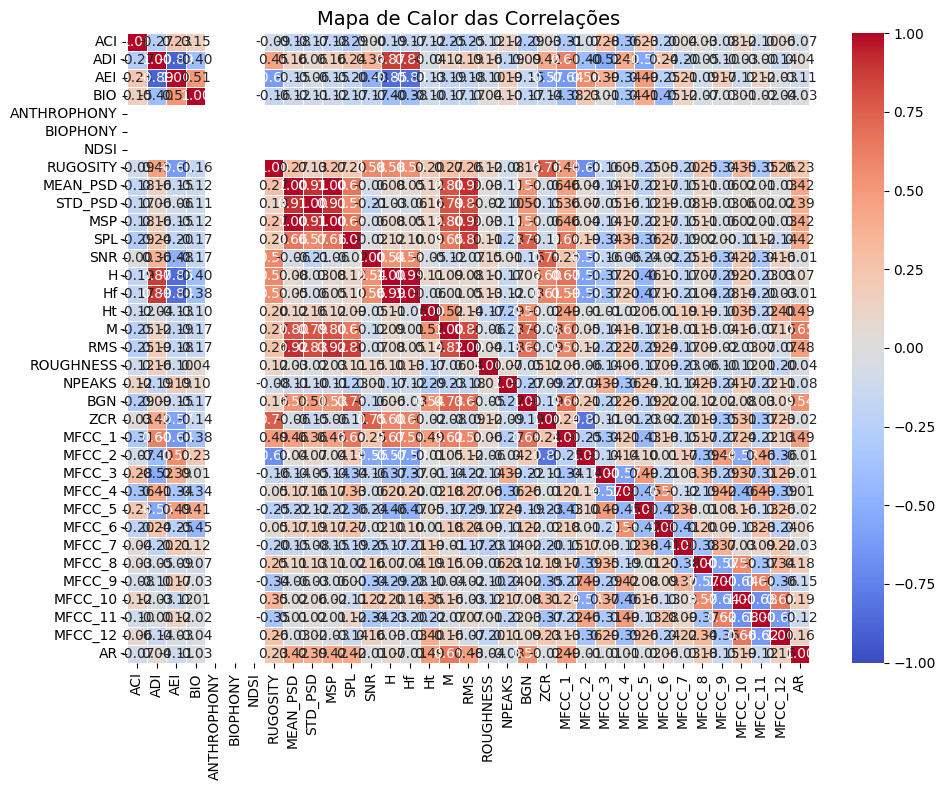

In [ ]:
# Calcula a matriz de correlação (usa o método de Pearson por padrão)
matriz_correlacao = X_train.corr()

# Exibe a matriz
print(matriz_correlacao)


# 1. Calcula a matriz de correlação (apenas para colunas numéricas, para evitar erros)
matriz_correlacao = df.select_dtypes(include='number').corr()

# 2. Configura o tamanho da imagem do gráfico (largura, altura)
plt.figure(figsize=(10, 8))

# 3. Cria o mapa de calor
sns.heatmap(
    matriz_correlacao, 
    annot=True,            # annot=True escreve os valores da correlação dentro de cada quadrado
    fmt=".2f",             # formata os números para mostrar apenas 2 casas decimais (ex: 0.85)
    cmap="coolwarm",       # define a paleta de cores (vermelho para positivo, azul para negativo)
    vmin=-1,               # fixa o valor mínimo da escala de cores em -1
    vmax=1,                # fixa o valor máximo da escala de cores em 1
    linewidths=0.5         # adiciona uma linha fina separando os quadrados para ficar mais elegante
)

# 4. Adiciona um título e exibe o gráfico
plt.title("Mapa de Calor das Correlações", fontsize=14)
plt.tight_layout() # Ajusta as margens para nada ficar cortado
plt.show()

# Testando a selecao de variáveis

Quando duas ou mais variáveis independentes (preditoras) são altamente correlacionadas entre si, o modelo de machine learning tem dificuldade em isolar o efeito individual de cada uma sobre a variável alvo. Isso gera dois grandes problemas:

Instabilidade: Pequenas alterações nos dados de entrada podem causar grandes mudanças nos coeficientes do modelo.

Dificuldade de Interpretação: Torna-se quase impossível determinar qual das variáveis correlacionadas é a que realmente "causa" o resultado, pois o modelo não consegue distinguir os efeitos.

O VIF (do inglês Variance Inflation Factor, ou Fator de Inflação da Variância) é uma métrica estatística usada para identificar e quantificar a multicolinearidade em um modelo de regressão ou em um conjunto de dados. Básicamente ele mede o quanto uma variável pode ser explicada pelas outras atuando como um "filtro de redundância", ele aponta quais colunas sâo apenas repetições de informações que já estão presentes em outras variáveis para simplificar o modelo sem perder o poder preditivo.

O VIF é calculado para cada variável independente. O resultado nos diz o seguinte:

VIF = 1: Não há correlação entre essa variável e as outras (ideal).

VIF entre 1 e 5: Existe uma correlação moderada, mas geralmente não é problemática para a maioria dos modelos.

VIF > 5 ou 10: Indica uma multicolinearidade severa. A variável está sendo explicada em grande parte pelas outras variáveis no conjunto de dados.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
thresh = 5.0
cols = X_train.columns
variables = np.arange(X_train.shape[1])
dropped = True

while dropped:
    dropped = False
    # Calcula o VIF para cada variável
    vif = [variance_inflation_factor(X_train.iloc[:, variables].values, ix)
            for ix in range(len(variables))]

    # Encontra o índice da variável com o maior VIF
    maxloc = vif.index(max(vif))

    # Se o maior VIF exceder o limite, remove
    if max(vif) > thresh:
        print(f"Removendo {cols[variables[maxloc]]} com VIF: {max(vif):.2f}")
        variables = np.delete(variables, maxloc)
        dropped = True

X_train_clean = X_train.iloc[:, variables]
X_test_clean = X_test.iloc[:, variables]

c:\Users\anate\miniconda3\envs\IntroAProgGenetic\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removendo MSP com VIF: inf
Removendo H com VIF: 11620.67
Removendo Hf com VIF: 576.42
Removendo Ht com VIF: 523.82
Removendo MFCC_1 com VIF: 198.10
Removendo BGN com VIF: 127.02
Removendo RMS com VIF: 114.51
Removendo ADI com VIF: 45.87
Removendo SPL com VIF: 24.49
Removendo NPEAKS com VIF: 18.04
Removendo ZCR com VIF: 14.94
Removendo MEAN_PSD com VIF: 13.05
Removendo M com VIF: 12.13
Removendo BIO com VIF: 11.38
Removendo MFCC_2 com VIF: 8.53
Removendo MFCC_3 com VIF: 7.37
Removendo MFCC_4 com VIF: 5.29
Removendo SNR com VIF: 5.19


Nota:  AEI tinham entrado, agora o BIO

18 variáveis foram removidas

# Treinamento dos modelos

É importa encontrar o modelo que case melhor com os seus dados (Livro)

Consideraremos Random Forest, XGBoost e SVM já que ambos gerenciam classes múltiplas automaticamente.

 Ao o parâmetro svm_C que controla a regularização do SVM (o equilíbrio entre suavizar a margem e errar menos no treino). O Optuna encontrou um valor de $C$ no estudo sem o VIF que conseguiu penalizar o modelo, anulando os efeitos nocivos da alta correlação sem precisar deletar nenhuma coluna

1. Definição da Função Objetivo para o Optuna

In [ ]:
def objective(trial):
    import time
    start = time.time()
    
    # 1. Parâmetros de escolha (Expandidos com novos modelos e reduções)
    bal_method = trial.suggest_categorical('balancing', ['ADASYN']) #['BorderlineSMOTE', 'SMOTE', 'UnderSampler', 'ClassWeight', 'ADASYN', 'SMOTEENN']
    
    # Incluindo os novos modelos convencionais ao lado dos anteriores
    model_name = trial.suggest_categorical('model', [
        'MLP' 
    ]) #  'RandomForest', 'SVM', 'XGBoost', 'KNN', 'MLP', ''LogisticRegression' 'KNN'
    
    # Nova escolha: Estratégias de Redução de Dimensionalidade (None significa manter todas as features originais)
    reduction_method = trial.suggest_categorical('reduction', [None]) #'PCA', 'LDA', 'UMAP'

    # 2. Definindo a técnica de balanceamento (Sampler)
    sampler = None
    class_weight = None
    
    if bal_method == 'SMOTE':
        sampler = SMOTE(random_state=42)
    elif bal_method == 'UnderSampler':
        sampler = RandomUnderSampler(random_state=42)
    elif bal_method == 'SMOTEENN':
        sampler = SMOTEENN(random_state=42)
    elif bal_method == 'BorderlineSMOTE':
        sampler = BorderlineSMOTE(random_state=42)
    elif bal_method == 'ADASYN':
        sampler = ADASYN(random_state=42)
    elif bal_method == 'ClassWeight':
        class_weight = 'balanced'
        
    # Regras de Poda (Pruning) se a combinação for inválida ou incompatível
    if model_name == 'XGBoost' and bal_method == 'ClassWeight':
        raise optuna.TrialPruned()
        
    # Modelos que NÃO aceitam class_weight nativamente (Evita que o código quebre se 'ClassWeight' for escolhido)
    if model_name in ['ComplementNB', 'KNN', 'MLP'] and bal_method == 'ClassWeight':
        raise optuna.TrialPruned()

    # 3. Definição do Componente de Redução de Dimensionalidade
    reducer = None
    if reduction_method == 'PCA':
        # O Optuna escolhe a porcentagem de variância a ser mantida
        pca_variance = trial.suggest_float('pca_variance', 0.85, 0.99)
        reducer = PCA(n_components=pca_variance, random_state=42)
        
    elif reduction_method == 'LDA':
        # LDA multiclasse projeta no máximo em: min(n_features, n_classes - 1)
        # Como são 22 classes, o limite máximo de componentes do LDA será 21
        max_lda_components = min(X_train.shape[1], len(np.unique(y_train)) - 1)
        lda_components = trial.suggest_int('lda_n_components', 2, max_lda_components)
        reducer = LinearDiscriminantAnalysis(n_components=lda_components)
        
    elif reduction_method == 'UMAP':
        # Instancie usando a biblioteca umap-learn (import umap)
        umap_components = trial.suggest_int('umap_n_components', 5, 30)
        reducer = umap.UMAP(n_components=umap_components, random_state=42)

    # 4. Definição do Modelo
    if model_name == 'RandomForest':
        modelo = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 50, 300, step=50),
            # max_depth=trial.suggest_categorical('rf_max_depth', [None, 5, 10, 15, 20]),
            max_depth=trial.suggest_categorical('rf_max_depth', [10, 20, 30, None]),
            # max_features=trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None]),
            max_features=trial.suggest_categorical('rf_max_features', ['sqrt', 0.2, 0.3, 0.5]),   # O segredo: testar frações. 0.3 = avalia ~230 features por vez.
            min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 5, 20),
            class_weight=class_weight,
            random_state=42, n_jobs=1
        )
    elif model_name == 'SVM':
        modelo = SVC(
            C=trial.suggest_float('svm_C', 1e-3, 1e2, log=True),
            gamma=trial.suggest_float('svm_gamma', 1e-4, 1e1, log=True),
            kernel='linear', probability=True,
            class_weight=class_weight,
            random_state=42
        )
    elif model_name == 'XGBoost':
        modelo = XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 300, step=50),
            max_depth=trial.suggest_int('xgb_max_depth', 3, 10),
            learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
            subsample=trial.suggest_float('xgb_subsample', 0, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0, 1.0),
            objective='multi:softmax',
            num_class=len(np.unique(y_train)),
            random_state=42, eval_metric='mlogloss', n_jobs=1
        )
        
    # --- NOVOS MODELOS CONVENCIONAIS ---
    elif model_name == 'LogisticRegression':
        modelo = LogisticRegression(
            C=trial.suggest_float('lr_C', 1e-4, 1e2, log=True),
            penalty=trial.suggest_categorical('lr_penalty', ['l1', 'l2']),
            multi_class='multinomial', 
            solver='saga', # 'saga' lida bem com grandes datasets, multiclasse e L1
            class_weight=class_weight,
            random_state=42, max_iter=2000, n_jobs=1
        )
        
    elif model_name == 'ComplementNB':
        modelo = ComplementNB(
            alpha=trial.suggest_float('nb_alpha', 1e-3, 1e1, log=True)
        )
        
    elif model_name == 'KNN':
        modelo = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_neighbors', 1, 30),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric=trial.suggest_categorical('knn_metric', ['euclidean', 'manhattan', 'cosine']),
            n_jobs=1
        )
        
    elif model_name == 'MLP':
        # Otimiza o tamanho de uma arquitetura simples (uma ou duas camadas)
        n_layers = trial.suggest_int('mlp_n_layers', 1, 2)
        if n_layers == 1:
            hidden_layer_sizes = (trial.suggest_int('mlp_layer1', 32, 256, step=32),)
        else:
            hidden_layer_sizes = (
                trial.suggest_int('mlp_layer1', 32, 512, step=32),
                trial.suggest_int('mlp_layer2', 16, 128, step=16)
            )
            
        modelo = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=trial.suggest_categorical('mlp_activation', ['relu', 'tanh']),
            alpha=trial.suggest_float('mlp_alpha', 1e-4, 1.0, log=True),
            learning_rate_init=trial.suggest_float('mlp_lr', 1e-4, 1e-2, log=True),
            random_state=42, max_iter=500
        )

    # 5. Construindo o Pipeline DINAMICAMENTE
    # Se for ComplementNB, usamos MinMaxScaler para garantir valores >= 0
    if model_name == 'ComplementNB':
        steps = [('scaler', MinMaxScaler())]
        print('Usando MinMaxScaler para ComplementNB')
    else:
        steps = [('scaler', StandardScaler())]
    
    # Se o PCA/LDA for usado com Naive Bayes, certifique-se de reescalar ou não gerar negativos
    if reducer is not None:
        steps.append(('reduction', reducer))
        if model_name == 'ComplementNB':
            # Adiciona um segundo scaler pós-redução para garantir que o PCA não deixe negativos
            steps.append(('post_reduction_scaler', MinMaxScaler()))
    
    # Se o Optuna escolheu uma técnica de oversampling/undersampling, entra aqui
    if sampler is not None:
        steps.append(('sampler', sampler))
        
    # Por fim, adicionamos o modelo
    steps.append(('classifier', modelo))
    
    # Criamos o pipeline usando a versão do imblearn
    pipeline = ImbPipeline(steps)

    # 6. Cross-Validation (Usando os dados ORIGINAIS)
    try:
        score = cross_val_score(pipeline, X_train_embeddings, y_train_embeddings, cv=3, scoring='balanced_accuracy', n_jobs=-1)
        score_mean = score.mean()
    except Exception as e:
        # Bloco de segurança caso alguma combinação matemática específica falhe/gere erro
        print(f"Trial {trial.number} falhou devido a erro: {e}")
        raise optuna.TrialPruned()

    elapsed = time.time() - start
    print(f"Trial {trial.number} ({model_name} + {reduction_method} + {bal_method}) terminou em {elapsed:.2f} segundos. Score: {score_mean:.4f}")

    return score_mean

Best is trial 21 with value: 0.7654361938081736

In [23]:
# ==========================================
# 3. CRIAÇÃO E EXECUÇÃO DO ESTUDO
# ==========================================
# Criamos o estudo linkando com o nome e o banco de dados que você pediu
study = optuna.create_study( study_name="experimento_embeddingsViTADASYN", 
    storage="sqlite:///estudo_MLP.db", 
    load_if_exists=True,      # Se o banco já existir, ele continua de onde parou
    direction="maximize"      # Queremos MAXIMIZAR a acurácia
)

print("Iniciando a otimização de hiperparâmetros...")

# Roda o experimento por N trials (tentativas)
# Você pode alterar o n_trials para 50, 100, etc. dependendo do seu tempo e poder de processamento.
study.optimize(objective, n_trials=10,n_jobs=-1) 

print("Otimização concluída!")

[I 2026-06-23 00:07:41,137] Using an existing study with name 'experimento_embeddingsViTADASYN' instead of creating a new one.


Iniciando a otimização de hiperparâmetros...


[I 2026-06-23 00:09:49,967] Trial 37 finished with value: 0.7367957493287142 and parameters: {'balancing': 'ADASYN', 'model': 'MLP', 'reduction': None, 'mlp_n_layers': 1, 'mlp_layer1': 64, 'mlp_activation': 'tanh', 'mlp_alpha': 0.021271945477261908, 'mlp_lr': 0.002372199539835945}. Best is trial 32 with value: 0.7462600761450179.


Trial 37 (MLP + None + ADASYN) terminou em 128.46 segundos. Score: 0.7368


[I 2026-06-23 00:09:52,394] Trial 36 finished with value: 0.7411430598178387 and parameters: {'balancing': 'ADASYN', 'model': 'MLP', 'reduction': None, 'mlp_n_layers': 1, 'mlp_layer1': 64, 'mlp_activation': 'tanh', 'mlp_alpha': 0.02113324225777576, 'mlp_lr': 0.0019588567865485404}. Best is trial 32 with value: 0.7462600761450179.


...

Trial 42 (MLP + None + ADASYN) terminou em 222.30 segundos. Score: 0.7271


[I 2026-06-23 00:11:27,930] Trial 39 finished with value: 0.7318282311701952 and parameters: {'balancing': 'ADASYN', 'model': 'MLP', 'reduction': None, 'mlp_n_layers': 1, 'mlp_layer1': 64, 'mlp_activation': 'tanh', 'mlp_alpha': 0.028603437416775984, 'mlp_lr': 0.0018078700218125583}. Best is trial 32 with value: 0.7462600761450179.


Trial 39 (MLP + None + ADASYN) terminou em 226.34 segundos. Score: 0.7318


[I 2026-06-23 00:11:34,835] Trial 43 finished with value: 0.7433942459510082 and parameters: {'balancing': 'ADASYN', 'model': 'MLP', 'reduction': None, 'mlp_n_layers': 1, 'mlp_layer1': 64, 'mlp_activation': 'tanh', 'mlp_alpha': 0.021027241423646443, 'mlp_lr': 0.0018904227536942755}. Best is trial 32 with value: 0.7462600761450179.


Trial 43 (MLP + None + ADASYN) terminou em 232.81 segundos. Score: 0.7434
Otimização concluída!


Treinamento e avaliação dos modelos

In [ ]:
experimento_embeddingsViTADASYN
 print(f"Número de Trials (Tentativas): {resumo.n_trials}")

In [ ]:
# Aponte para o arquivo que você quer inspecionar
nome_do_banco = "sqlite:///estudo_Exp1_Features_Acusticas.db"  
# OFOICIAL estudo_ADASYN2
# Puxa o resumo de todos os estudos lá dentro
resumos = optuna.study.get_all_study_summaries(storage=nome_do_banco)

print(f"Total de estudos encontrados: {len(resumos)}\n")

for resumo in resumos:
    print(f"Nome do Estudo: {resumo.study_name}")
    print(f"Melhor valor até agora: {resumo.best_trial.value if resumo.best_trial else 'Nenhum trial concluído'}")
    print("-" * 30)

Total de estudos encontrados: 8

Nome do Estudo: estudo_RandomForest
Número de Trials (Tentativas): 95
Melhor valor até agora: 0.6126150954064362
------------------------------
Nome do Estudo: estudo_SVM
Número de Trials (Tentativas): 50
Melhor valor até agora: 0.7060176513597229
------------------------------
Nome do Estudo: estudo_XGBoost
Número de Trials (Tentativas): 50
Melhor valor até agora: 0.6593628500672343
------------------------------
Nome do Estudo: estudo_LogisticRegression
Número de Trials (Tentativas): 62
Melhor valor até agora: 0.6648827920994844
------------------------------
Nome do Estudo: estudo_ComplementNB
Número de Trials (Tentativas): 80
Melhor valor até agora: 0.11367427977715985
------------------------------
Nome do Estudo: estudo_KNN
Número de Trials (Tentativas): 120
Melhor valor até agora: 0.6301496504914432
------------------------------
Nome do Estudo: estudo_MLP
Número de Trials (Tentativas): 116
Melhor valor até agora: 0.7389229935238771
-------------

In [5]:
import optuna

# 1. Defina o banco e o nome exato do estudo encontrado
nome_do_banco = "sqlite:///estudo_Exp1_Features_Acusticas.db"
nome_do_estudo = "estudo_XGBoost"

# 2. Carregue o estudo completo
study = optuna.load_study(study_name=nome_do_estudo, storage=nome_do_banco)

# 3. Inspecionando as configurações gerais
print("=== CONFIGURAÇÕES DO ESTUDO ===")
print(f"Nome do Estudo: {study.study_name}")
print(f"Direção da Otimização: {study.direction}") # ex: MINIMIZE ou MAXIMIZE

# 4. Inspecionando o Sampler (onde a seed geralmente é configurada)
print("\n=== CONFIGURAÇÕES DO SAMPLER ===")
print(f"Objeto Sampler: {study.sampler}")
print(f"Classe do Sampler: {study.sampler.__class__.__name__}")

# Dependendo da versão do Optuna e do Sampler (ex: TPESampler, RandomSampler),
# a seed ou as configurações internas do sampler podem ser acessadas assim:
if hasattr(study.sampler, '_random_sampler'):
    print(f"Seed do RandomSampler interno: {getattr(study.sampler._random_sampler, '_seed', 'Não encontrada')}")
elif hasattr(study.sampler, '_seed'):
    print(f"Seed do Sampler: {study.sampler._seed}")

# 5. Inspecionando Atributos Customizados (User e System)
print("\n=== ATRIBUTOS ===")
print(f"Atributos do Usuário (User Attrs): {study.user_attrs}")
print(f"Atributos do Sistema (System Attrs): {study.system_attrs}")

=== CONFIGURAÇÕES DO ESTUDO ===
Nome do Estudo: estudo_XGBoost
Direção da Otimização: 2

=== CONFIGURAÇÕES DO SAMPLER ===
Objeto Sampler: TPESampler
Classe do Sampler: TPESampler
Seed do RandomSampler interno: Não encontrada

=== ATRIBUTOS ===
Atributos do Usuário (User Attrs): {}
Atributos do Sistema (System Attrs): {}


C:\Users\anate\AppData\Local\Temp\ipykernel_23484\1541304016.py:30: FutureWarning: system_attrs has been deprecated in v3.1.0. This feature will be removed in v5.0.0. See https://github.com/optuna/optuna/releases/tag/v3.1.0.
  print(f"Atributos do Sistema (System Attrs): {study.system_attrs}")


In [ ]:
# 1. Carregue o estudo de onde ele está salvo

study = optuna.load_study(
    study_name="experimento_embeddingsViTADASYN",          # O nome do estudo que você quer ver
    storage="sqlite:///estudo_MLP.db"  # O arquivo .db onde ele está
)


# 2. Puxe as informações do melhor trial
melhor_trial = study.best_trial
# 3. Exiba os resultados de forma organizada

print("=== RESULTADO DA OTIMIZAÇÃO ===")
print(f"Trial Número: {melhor_trial.number}")
print(f"Melhor Métrica (Ex: Acurácia): {melhor_trial.value:.4f}")



print("\nMelhores Hiperparâmetros encontrados:")

for parametro, valor in melhor_trial.params.items():
    print(f"  -> {parametro}: {valor}") 

=== RESULTADO DA OTIMIZAÇÃO ===
Trial Número: 32
Melhor Métrica (Ex: Acurácia): 0.7463

Melhores Hiperparâmetros encontrados:
  -> balancing: ADASYN
  -> model: MLP
  -> reduction: None
  -> mlp_n_layers: 1
  -> mlp_layer1: 64
  -> mlp_activation: tanh
  -> mlp_alpha: 0.030410095410308542
  -> mlp_lr: 0.000840380407443894


Interpretação Prática: A remoção de recursos via VIF foi muito agressiva para as características de áudio do seu dataset. Embora as variáveis fossem altamente correlacionadas, elas continham informações complementares essenciais para o problema multiclasse. O algoritmo SVM se mostrou robusto o suficiente para processar essa redundância e usar a base completa para traçar fronteiras de decisão mais precisas do que faria com os dados reduzidos.

Treinamento com o df apos a remocao com o VIF

Reconstruindo os melhores classificadores

In [24]:
best = study.best_params


 VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO
Modelo Base: MLP
Balanceamento: ADASYN
Redução de Dimensionalidade: None

Parâmetros detalhados instanciados no Pipeline:

--- SCALER ---
  - copy: True
  - with_mean: True
  - with_std: True

--- BALANCE ---
  - n_neighbors: 5
  - random_state: 42
  - sampling_strategy: auto

--- CLASSIFIER ---
  - activation: tanh
  - alpha: 0.030410095410308542
  - batch_size: auto
  - beta_1: 0.9
  - beta_2: 0.999
  - early_stopping: False
  - epsilon: 1e-08
  - hidden_layer_sizes: (64,)
  - learning_rate: constant
  - learning_rate_init: 0.000840380407443894
  - max_fun: 15000
  - max_iter: 500
  - momentum: 0.9
  - n_iter_no_change: 10
  - nesterovs_momentum: True
  - power_t: 0.5
  - random_state: 42
  - shuffle: True
  - solver: adam
  - tol: 0.0001
  - validation_fraction: 0.1
  - verbose: False
  - warm_start: False

[2/3] Treinando o modelo final com toda a base de treino filtrada...
[3/3] Avaliando o desempenho na base de teste...

            

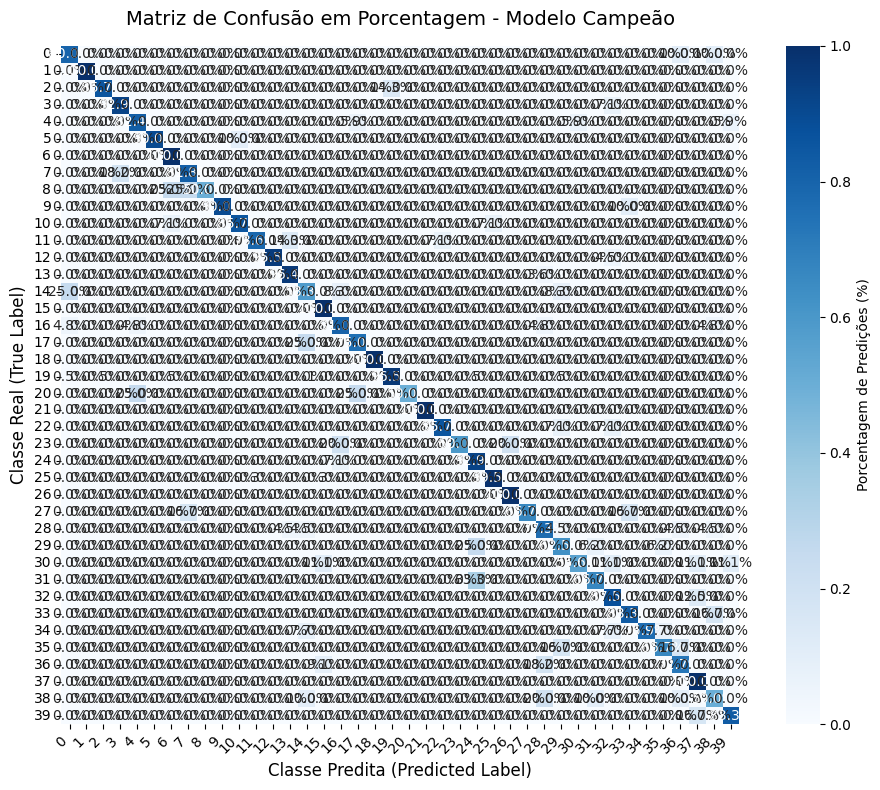

In [25]:
# 1. Configura o método de balanceamento campeão
if best['balancing'] == 'SMOTE':
    best_sampler = SMOTE(random_state=42)
elif best['balancing'] == 'UnderSampler':
    best_sampler = RandomUnderSampler(random_state=42)
elif best['balancing'] == 'SMOTEENN':
    best_sampler = SMOTEENN(random_state=42)
elif best['balancing'] == 'BorderlineSMOTE':
    best_sampler = BorderlineSMOTE(random_state=42)
elif best['balancing'] == 'ADASYN':
    best_sampler = ADASYN(random_state=42)
else:
    best_sampler = 'passthrough'

best_class_weight = 'balanced' if best['balancing'] == 'ClassWeight' else None

# 2. Configura o classificador campeão com seus respectivos hiperparâmetros
if best['model'] == 'RandomForest':
    best_modelo = RandomForestClassifier(
        n_estimators=best['rf_n_estimators'],
        max_depth=best['rf_max_depth'],
        max_features=best['rf_max_features'],           # ADICIONADO
        min_samples_split=best['rf_min_samples_split'], # ADICIONADO
        min_samples_leaf=best['rf_min_samples_leaf'],   # ADICIONADO
        class_weight=best_class_weight,
        random_state=42,
        n_jobs=1
    )

 
elif best['model'] == 'SVM':
    best_modelo = SVC(
        C=best['svm_C'],
        gamma=best['svm_gamma'], # ADICIONADO
        kernel='linear',
        class_weight=best_class_weight,
        random_state=42,
        cache_size=2000
    )
    
elif best['model'] == 'MLP':
    if best['mlp_n_layers'] == 1:
        hidden_layers = (best['mlp_layer1'],) 
    else:
        hidden_layers = (best['mlp_layer1'], best['mlp_layer2'])
        
    best_modelo = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=best['mlp_activation'],
        alpha=best['mlp_alpha'],
        learning_rate_init=best['mlp_lr'],
        random_state=42, 
        max_iter=500
    )
elif best['model'] == 'XGBoost':
    num_class = len(np.unique(y_train))
    best_modelo = XGBClassifier(
        n_estimators=best['xgb_n_estimators'],
        max_depth=best['xgb_max_depth'],
        learning_rate=best['xgb_learning_rate'],
        subsample=best['xgb_subsample'],               # ADICIONADO
        colsample_bytree=best['xgb_colsample_bytree'], # ADICIONADO
        objective='multi:softprob', 
        num_class=num_class,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=1
    )
elif best['model'] == 'LogisticRegression':
    best_modelo = LogisticRegression(
        C=best['lr_C'],                  
        penalty=best['lr_penalty'],      # ADICIONADO
        solver='saga',                   # ADICIONADO (Necessário para L1/L2)
        class_weight=best_class_weight,  
        random_state=42,
        max_iter=2000,                   # CORRIGIDO (estava 1000, na função objetivo é 2000)
        n_jobs=1
    )


    
elif best['model'] == 'KNN':
    best_modelo = KNeighborsClassifier(
        n_neighbors=best['knn_neighbors'], # CORRIGIDO (o nome da chave estava errado)
        weights=best['knn_weights'], 
        metric=best['knn_metric'],         # ADICIONADO
        n_jobs=1
    )


# ---------------------------------------------------------------------
# 3. Monta o Redutor de Dimensionalidade Campeão (FALTAVA NO CÓDIGO 2)
# ---------------------------------------------------------------------
best_reducer = 'passthrough'
if best.get('reduction') == 'PCA':
    best_reducer = PCA(n_components=best['pca_variance'], random_state=42)
elif best.get('reduction') == 'LDA':
    best_reducer = LinearDiscriminantAnalysis(n_components=best['lda_n_components'])
elif best.get('reduction') == 'UMAP':
    best_reducer = umap.UMAP(n_components=best['umap_n_components'], random_state=42)

# ---------------------------------------------------------------------
# 4. Monta o pipeline final DINAMICAMENTE (Igual à função objetivo)
# ---------------------------------------------------------------------
final_steps = []

# Escolha do Scaler
if best['model'] == 'ComplementNB':
    final_steps.append(('scaler', MinMaxScaler()))
else:
    final_steps.append(('scaler', StandardScaler()))

# Adiciona Redutor se existir
if best.get('reduction') is not None:
    final_steps.append(('reduction', best_reducer))
    if best['model'] == 'ComplementNB':
        final_steps.append(('post_reduction_scaler', MinMaxScaler()))

# Adiciona Balanceamento
final_steps.append(('balance', best_sampler))

# Adiciona o Modelo
final_steps.append(('classifier', best_modelo))

final_pipeline = ImbPipeline(steps=final_steps)


# =====================================================================
# CONFERÊNCIA DO MODELO E PIPELINE
# =====================================================================
print("\n" + "="*50)
print(" VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO")
print("="*50)
print(f"Modelo Base: {best['model']}")
print(f"Balanceamento: {best['balancing']}")
print(f"Redução de Dimensionalidade: {best.get('reduction', 'Nenhuma')}")
print("\nParâmetros detalhados instanciados no Pipeline:")

for step_name, step_obj in final_pipeline.named_steps.items():
    if step_obj != 'passthrough':
        print(f"\n--- {step_name.upper()} ---")
        for param, valor in step_obj.get_params().items():
            print(f"  - {param}: {valor}")
print("="*50 + "\n")
# =====================================================================

print("[2/3] Treinando o modelo final com toda a base de treino filtrada...")
final_pipeline.fit(X_train_embeddings, y_train_embeddings)
  
# --- PASSO 5: PREDIÇÃO E MÉTRICAS ---

print("[3/3] Avaliando o desempenho na base de teste...")
# Predição de classes
y_pred = final_pipeline.predict(X_test_embeddings)
# Predição de probabilidades
# y_prob = final_pipeline.predict_proba(X_test_embeddings)

print("\n" + "="*50)
print("            MÉTRICAS DE AVALIAÇÃO FINAL")
print("="*50)

# Cálculo das métricas originais
acc_geral = accuracy_score(y_test_embeddings, y_pred)
acc_balanceada = balanced_accuracy_score(y_test_embeddings, y_pred)

# Novas métricas (F1, TOP 3 e TOP 5)
f1 = f1_score(y_test_embeddings, y_pred, average='weighted')

classes_do_modelo = final_pipeline.classes_
# acc_top3 = top_k_accuracy_score(y_test_embeddings, y_prob, k=3, labels=classes_do_modelo)

print(f"Acurácia Geral:                 {acc_geral:.4f}")
print(f"Acurácia Balanceada:            {acc_balanceada:.4f}")
# print(f"Acurácia TOP 3:                 {acc_top3:.4f}")

print("\nRelatório de Classificação por Classe (Precision, Recall, F1-score):")
print(classification_report(y_test_embeddings, y_pred))
print("="*50)

# Calcula a matriz de confusão com porcentagens
cm_percent = confusion_matrix(y_test_embeddings, y_pred, normalize='true')

plt.figure(figsize=(10, 8))

# fmt='.1%' transforma automaticamente o decimal (ex: 0.953) em porcentagem (95.3%)
# Opcional: Adicionei os nomes das classes nos eixos para facilitar a leitura
sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='Blues', square=True,
            xticklabels=classes_do_modelo, yticklabels=classes_do_modelo,
            cbar_kws={'label': 'Porcentagem de Predições (%)'})

plt.title('Matriz de Confusão em Porcentagem - Modelo Campeão', fontsize=14, pad=15)
plt.ylabel('Classe Real (True Label)', fontsize=12)
plt.xlabel('Classe Predita (Predicted Label)', fontsize=12)

# Rotaciona os rótulos do eixo X se forem nomes compridos
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()


[3/3] Avaliando o desempenho na base de teste...

            MÉTRICAS DE AVALIAÇÃO FINAL
Acurácia Geral:                 0.9050
Acurácia Balanceada:            0.7643

Relatório de Classificação por Classe (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.88      1.00      0.93         7
           2       0.87      0.93      0.90        14
           3       0.93      0.93      0.93        14
           4       0.83      0.88      0.86        17
           5       1.00      0.90      0.95        10
           6       0.75      1.00      0.86        12
           7       0.92      1.00      0.96        11
           8       1.00      0.50      0.67         4
           9       0.91      1.00      0.95        10
          10       0.91      0.71      0.80        14
          11       1.00      0.79      0.88        14
          12       1.00      0.95      0.98        22
     

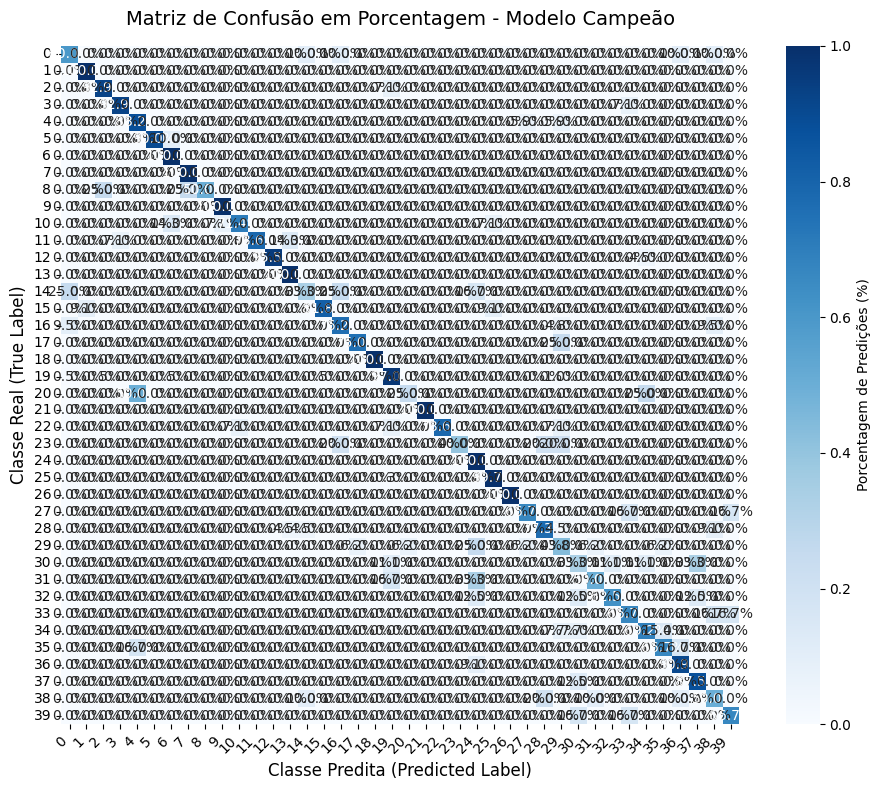

In [21]:
print("[3/3] Avaliando o desempenho na base de teste...")
# Predição de classes
y_pred = final_pipeline.predict(X_test_embeddings)
# Predição de probabilidades

print("\n" + "="*50)
print("            MÉTRICAS DE AVALIAÇÃO FINAL")
print("="*50)

# Cálculo das métricas originais
acc_geral = accuracy_score(y_test_embeddings, y_pred)
acc_balanceada = balanced_accuracy_score(y_test_embeddings, y_pred)

# Novas métricas (F1, TOP 3 e TOP 5)
f1 = f1_score(y_test_embeddings, y_pred, average='weighted')

classes_do_modelo = final_pipeline.classes_
# acc_top3 = top_k_accuracy_score(y_test_embeddings, y_prob, k=3, labels=classes_do_modelo)

print(f"Acurácia Geral:                 {acc_geral:.4f}")
print(f"Acurácia Balanceada:            {acc_balanceada:.4f}")
# print(f"Acurácia TOP 3:                 {acc_top3:.4f}")

print("\nRelatório de Classificação por Classe (Precision, Recall, F1-score):")
print(classification_report(y_test_embeddings, y_pred))
print("="*50)

# Calcula a matriz de confusão com porcentagens
cm_percent = confusion_matrix(y_test_embeddings, y_pred, normalize='true')

plt.figure(figsize=(10, 8))

# fmt='.1%' transforma automaticamente o decimal (ex: 0.953) em porcentagem (95.3%)
# Opcional: Adicionei os nomes das classes nos eixos para facilitar a leitura
sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='Blues', square=True,
            xticklabels=classes_do_modelo, yticklabels=classes_do_modelo,
            cbar_kws={'label': 'Porcentagem de Predições (%)'})

plt.title('Matriz de Confusão em Porcentagem - Modelo Campeão', fontsize=14, pad=15)
plt.ylabel('Classe Real (True Label)', fontsize=12)
plt.xlabel('Classe Predita (Predicted Label)', fontsize=12)

# Rotaciona os rótulos do eixo X se forem nomes compridos
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()



 VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO
Modelo Base: RandomForest
Balanceamento: Nenhum

Parâmetros detalhados instanciados:
  - C: 2.2771803526303027
  - class_weight: None
  - dual: False
  - fit_intercept: True
  - intercept_scaling: 1
  - l1_ratio: None
  - max_iter: 2000
  - multi_class: deprecated
  - n_jobs: 1
  - penalty: l1
  - random_state: 42
  - solver: saga
  - tol: 0.0001
  - verbose: 0
  - warm_start: False

[2/3] Treinando o modelo final com toda a base de treino filtrada...


c:\Users\anate\miniconda3\envs\IntroAProgGenetic\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[3/3] Avaliando o desempenho na base de teste...

            MÉTRICAS DE AVALIAÇÃO FINAL
Acurácia Geral:                 0.8744
Acurácia Balanceada:            0.7072
F1-Score (Weighted):            0.8726
Acurácia TOP 3:                 0.9394
Acurácia TOP 5:                 0.9570
Cohen's Kappa:                  0.8504
Matthews Corr. Coef. (MCC):     0.8505
ROC AUC (OVR, Weighted):        0.9932

Relatório de Classificação por Classe (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.67      0.40      0.50        10
           1       0.83      0.71      0.77         7
           2       0.81      0.93      0.87        14
           3       0.79      0.79      0.79        14
           4       0.62      0.76      0.68        17
           5       0.88      0.70      0.78        10
           6       0.71      0.91      0.80        11
           7       1.00      0.91      0.95        11
           8       1.00      0.50      0.

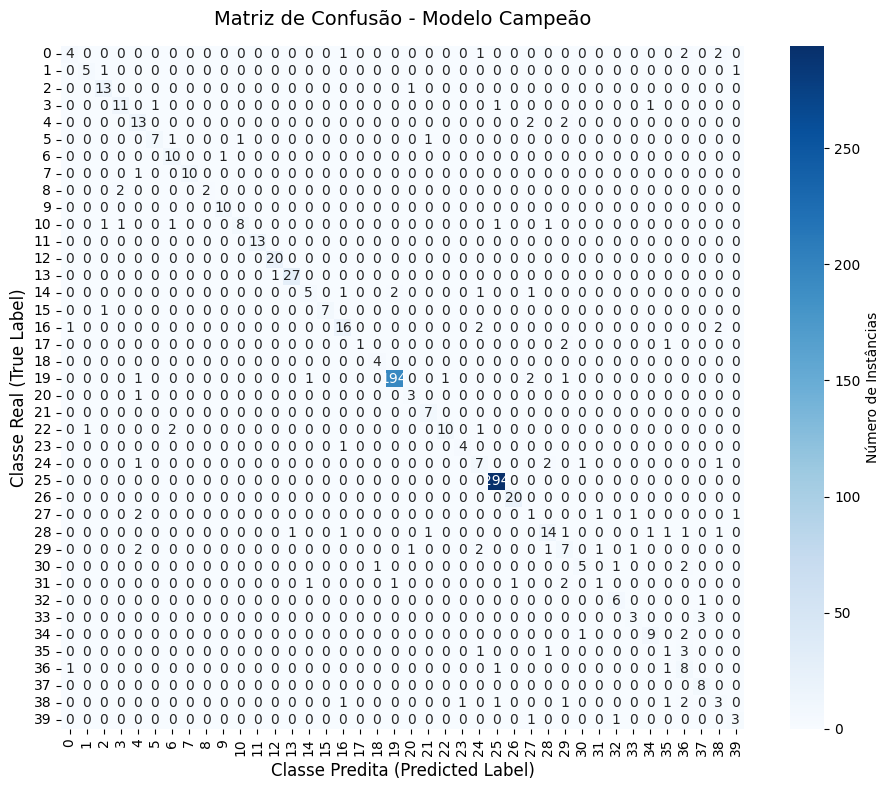

In [ ]:

best_sampler = 'passthrough'
best_class_weight =  None

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 80),
    activation='tanh',
    alpha=0.07815585639352841,
    learning_rate_init=0.0012428584136290875,
    random_state=42, 
    max_iter=500
)

# 3. Monta o pipeline final
final_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('balance', best_sampler),
    ('classifier', best_modelo)
])

# =====================================================================
# CONFERÊNCIA DO MODELO E PIPELINE
# =====================================================================
print("\n" + "="*50)
print(" VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO")
print("="*50)
print(f"Modelo Base: {best['model']}")
print(f"Balanceamento: {best['balancing']}")
print("\nParâmetros detalhados instanciados:")
# O get_params() extrai um dicionário com tudo o que o modelo vai usar
for param, valor in final_pipeline.named_steps['classifier'].get_params().items():
    print(f"  - {param}: {valor}")
print("="*50 + "\n")
# =====================================================================

print("[2/3] Treinando o modelo final com toda a base de treino filtrada...")
final_pipeline.fit(X_train, y_train)

# --- PASSO 5: PREDIÇÃO E MÉTRICAS ---

print("[3/3] Avaliando o desempenho na base de teste...")
# Predição de classes
y_pred = final_pipeline.predict(X_test)
# Predição de probabilidades (necessário para o ROC AUC e Top-K Accuracy)
y_prob = final_pipeline.predict_proba(X_test)

print("\n" + "="*50)
print("            MÉTRICAS DE AVALIAÇÃO FINAL")
print("="*50)

# Cálculo das métricas originais
acc_geral = accuracy_score(y_test, y_pred)
acc_balanceada = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# Novas métricas (F1, TOP 3 e TOP 5)
f1 = f1_score(y_test, y_pred, average='weighted')

classes_do_modelo = final_pipeline.classes_
acc_top3 = top_k_accuracy_score(y_test, y_prob, k=3, labels=classes_do_modelo)
acc_top5 = top_k_accuracy_score(y_test, y_prob, k=5, labels=classes_do_modelo)

print(f"Acurácia Geral:                 {acc_geral:.4f}")
print(f"Acurácia Balanceada:            {acc_balanceada:.4f}")
print(f"F1-Score (Weighted):            {f1:.4f}")
print(f"Acurácia TOP 3:                 {acc_top3:.4f}")
print(f"Acurácia TOP 5:                 {acc_top5:.4f}")
print(f"Cohen's Kappa:                  {kappa:.4f}")
print(f"Matthews Corr. Coef. (MCC):     {mcc:.4f}")
print(f"ROC AUC (OVR, Weighted):        {roc_auc:.4f}")

print("\nRelatório de Classificação por Classe (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))
print("="*50)

# Calcula a matriz de confusão simples
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Número de Instâncias'})

plt.title('Matriz de Confusão - Modelo Campeão', fontsize=14, pad=15)
plt.ylabel('Classe Real (True Label)', fontsize=12)
plt.xlabel('Classe Predita (Predicted Label)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# 1. DEFINIÇÃO DOS MODELOS BASE (Com limite de CPU)
# =====================================================================
svm = SVC(
        C=48.60657092, gamma=0.0171980995,
        kernel='rbf',
        probability=True, 
        random_state=42
)

xgboost = XGBClassifier(
         n_estimators=250,
         max_depth=10,
         learning_rate=0.15326902897769398,
         subsample=0.8799655876904354, # Corrigido de min_subsample para subsample (padrão XGBoost)
         colsample_bytree=0.7700172376249407,
         objective='multi:softprob', 
         num_class=40,
         random_state=42,
         eval_metric='mlogloss',
         n_jobs=1
     )

logistic = LogisticRegression(
    C=2.2771803526303027,
    penalty='l1',
    solver='saga', 
    random_state=42, 
    max_iter=2000, 
    n_jobs=1
)


mlp = MLPClassifier(
    hidden_layer_sizes=(256, 80),
    activation='tanh',
    alpha=0.07815585639352841,
    learning_rate_init=0.0012428584136290875,
    random_state=42, 
    max_iter=500
)

# =====================================================================
# 2. STACKING E PIPELINE FINAL
# =====================================================================
# Substituímos o StackingRegressor por StackingClassifier
# Substituímos o Lasso (Regressão) por LogisticRegression (Classificação)
# Utilizamos penalty='l1' para manter a característica de "seleção de features/esparsidade" que o Lasso tinha
meta_classifier = LogisticRegression(penalty='l1', solver='saga', random_state=42, max_iter=2000, n_jobs=1)

model = StackingClassifier(
    estimators=[ ('xgboost', xgboost), ('mlp', mlp), ('svm', svm), ('logistic', logistic)],
    final_estimator=meta_classifier, 
    n_jobs=1, 
    cv=5
)

# Padronizando o nome da variável para final_pipeline
final_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', model)
])

# =====================================================================
# CONFERÊNCIA DO MODELO E PIPELINE
# =====================================================================
print("\n" + "="*50)
print(" VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO")
print("="*50)
print(f"Modelo Base: {best['model']}")
print(f"Balanceamento: {best['balancing']}")
print("\nParâmetros detalhados instanciados:")
# O get_params() extrai um dicionário com tudo o que o modelo vai usar
for param, valor in final_pipeline.named_steps['classifier'].get_params().items():
    print(f"  - {param}: {valor}")
print("="*50 + "\n")
# =====================================================================

print("[2/3] Treinando o modelo final com toda a base de treino filtrada...")
final_pipeline.fit(X_train, y_train)

# --- PASSO 5: PREDIÇÃO E MÉTRICAS ---

print("[3/3] Avaliando o desempenho na base de teste...")
# Predição de classes
y_pred = final_pipeline.predict(X_test)
# Predição de probabilidades (necessário para o ROC AUC e Top-K Accuracy)
y_prob = final_pipeline.predict_proba(X_test)

print("\n" + "="*50)
print("            MÉTRICAS DE AVALIAÇÃO FINAL")
print("="*50)

# Cálculo das métricas originais
acc_geral = accuracy_score(y_test, y_pred)
acc_balanceada = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

# Novas métricas (F1, TOP 3 e TOP 5)
f1 = f1_score(y_test, y_pred, average='weighted')

classes_do_modelo = final_pipeline.classes_
acc_top3 = top_k_accuracy_score(y_test, y_prob, k=3, labels=classes_do_modelo)
acc_top5 = top_k_accuracy_score(y_test, y_prob, k=5, labels=classes_do_modelo)

print(f"Acurácia Geral:                 {acc_geral:.4f}")
print(f"Acurácia Balanceada:            {acc_balanceada:.4f}")
print(f"F1-Score (Weighted):            {f1:.4f}")
print(f"Acurácia TOP 3:                 {acc_top3:.4f}")
print(f"Acurácia TOP 5:                 {acc_top5:.4f}")
print(f"Cohen's Kappa:                  {kappa:.4f}")
print(f"Matthews Corr. Coef. (MCC):     {mcc:.4f}")
print(f"ROC AUC (OVR, Weighted):        {roc_auc:.4f}")

print("\nRelatório de Classificação por Classe (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))
print("="*50)

# Calcula a matriz de confusão simples
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Número de Instâncias'})

plt.title('Matriz de Confusão - Modelo Campeão', fontsize=14, pad=15)
plt.ylabel('Classe Real (True Label)', fontsize=12)
plt.xlabel('Classe Predita (Predicted Label)', fontsize=12)

plt.tight_layout()
plt.show()


 VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO
Modelo Base: XGBoost
Balanceamento: Nenhum

Parâmetros detalhados instanciados:
  - cv: 5
  - estimators: [('xgboost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7700172376249407, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15326902897769398,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=1, num_class=22, ...)), ('mlp', MLPClassifier(activation='tanh', alpha=0.078


 VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO

Parâmetros detalhados instanciados:
  - estimators: [('xgb', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7700172376249407, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15326902897769398,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=1, num_class=22, ...)), ('mlp', MLPClassifier(activation='tanh', alpha=0.07815585639352841,
              hidden_layer_sizes=(256, 80

c:\Users\anate\miniconda3\envs\IntroAProgGenetic\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[3/3] Avaliando o desempenho na base de teste...

            MÉTRICAS DE AVALIAÇÃO FINAL
Acurácia Geral:                 0.8998
Acurácia Balanceada:            0.7470
Cohen's Kappa:                  0.8804
Matthews Corr. Coef. (MCC):     0.8805
ROC AUC (OVR, Weighted):        0.9967

Relatório de Classificação por Classe (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        10
           1       0.80      0.57      0.67         7
           2       0.93      1.00      0.97        14
           3       0.92      0.86      0.89        14
           4       0.73      0.94      0.82        17
           5       0.89      0.80      0.84        10
           6       0.85      1.00      0.92        11
           7       1.00      0.91      0.95        11
           8       1.00      0.75      0.86         4
           9       1.00      1.00      1.00        10
          10       0.83      0.77      0.80       

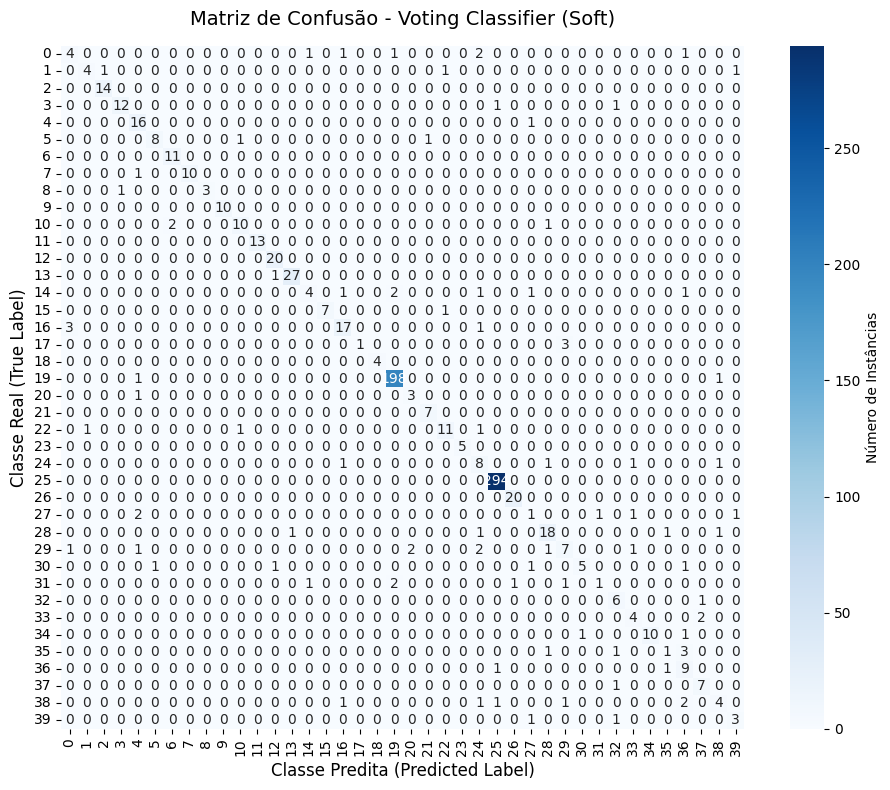

In [ ]:
# Lembre-se de importar seus modelos base (SVC, XGBClassifier, MLPClassifier) caso não estejam no topo do script

# =====================================================================
# 1. DEFINIÇÃO DOS MODELOS BASE (Com limite de CPU)
# =====================================================================
svm = SVC(
        C=48.60657092, gamma=0.0171980995,
        kernel='rbf',
        probability=True, # Essencial para o soft voting
        random_state=42
)

xgboost = XGBClassifier(
        n_estimators=250,
        max_depth=10,
        learning_rate=0.15326902897769398,
        subsample=0.8799655876904354, 
        colsample_bytree=0.7700172376249407,
        objective='multi:softprob', 
        num_class=22,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=1
    )

logistic = LogisticRegression(
    C=2.2771803526303027,
    penalty='l1',
    solver='saga', 
    random_state=42, 
    max_iter=2000, 
    n_jobs=1
)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 80),
    activation='tanh',
    alpha=0.07815585639352841,
    learning_rate_init=0.0012428584136290875,
    random_state=42, 
    max_iter=500
)

# =====================================================================
# 2. VOTING CLASSIFIER E PIPELINE FINAL
# =====================================================================
# O VotingClassifier substitui o Stacking e não precisa de 'final_estimator'
model = VotingClassifier(
    estimators=[('xgb', xgboost), ('mlp', mlp), ('svm', svm), ('logistic', logistic)],
    voting='soft', # 'soft' tira a média das probabilidades e permite usar predict_proba()
    n_jobs=1
)

final_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', model)
])

# =====================================================================
# 3. CONFERÊNCIA DO MODELO E PIPELINE
# =====================================================================
print("\n" + "="*50)
print(" VERIFICAÇÃO DA ARQUITETURA DO MODELO CAMPEÃO")
print("="*50)
print("\nParâmetros detalhados instanciados:")

for param, valor in final_pipeline.named_steps['classifier'].get_params().items():
    print(f"  - {param}: {valor}")
print("="*50 + "\n")

# =====================================================================
# 4. TREINAMENTO
# =====================================================================
print("[2/3] Treinando o modelo final com toda a base de treino filtrada...")
final_pipeline.fit(X_train, y_train)

# =====================================================================
# 5. PREDIÇÃO E MÉTRICAS
# =====================================================================
print("[3/3] Avaliando o desempenho na base de teste...")
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test) # Funciona perfeitamente por causa do voting='soft'

print("\n" + "="*50)
print("            MÉTRICAS DE AVALIAÇÃO FINAL")
print("="*50)

# Cálculo das métricas
acc_geral = accuracy_score(y_test, y_pred)
acc_balanceada = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print(f"Acurácia Geral:                 {acc_geral:.4f}")
print(f"Acurácia Balanceada:            {acc_balanceada:.4f}")
print(f"Cohen's Kappa:                  {kappa:.4f}")
print(f"Matthews Corr. Coef. (MCC):     {mcc:.4f}")
print(f"ROC AUC (OVR, Weighted):        {roc_auc:.4f}")

print("\nRelatório de Classificação por Classe (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))
print("="*50)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            cbar_kws={'label': 'Número de Instâncias'})

plt.title('Matriz de Confusão - Voting Classifier (Soft)', fontsize=14, pad=15)
plt.ylabel('Classe Real (True Label)', fontsize=12)
plt.xlabel('Classe Predita (Predicted Label)', fontsize=12)

plt.tight_layout()
plt.show()